# Deteksi Tanda Tangan (SIGNATURE DETECTION)
Muhammad Yani | F1G124069 | Kelas C  
Pipeline: crop ROI → grayscale → thresholding (global, Otsu, adaptive) → opening + closing → fitur area → aturan keputusan → pengujian.

## 1. Setup & ROI
Jalankan notebook dari folder yang berisi `citra/`. ROI utama = tanda tangan **Dekan**; Rektor dan pemilik ijazah sebagai tambahan.

In [1]:
import cv2, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = sorted(glob.glob('citra/*.jpeg'))

# ROI (x1, y1, x2, y2) pada citra tegak 1600x1132
ROI_POSITIF = {
    'dekan'  : (990, 760, 1400, 920),   # ROI utama
    'rektor' : (230, 815, 630, 925),
    'pemilik': (715, 975, 810, 1030),
}
ROI_NEGATIF = {
    'kertas_kosong_1': (60, 640, 460, 750),
    'kertas_kosong_2': (1100, 400, 1500, 520),
    'kertas_kosong_3': (30, 820, 230, 930),
    'teks_cetak_1'   : (230, 925, 650, 975),
    'teks_cetak_2'   : (180, 590, 500, 640),
}
UTAMA = 'dekan'

def tegakkan(img): return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)   # scan miring 90 derajat
def crop(img, roi): x1,y1,x2,y2 = roi; return img[y1:y2, x1:x2]
def ke_gray(bgr): return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

## 2. Crop & Grayscale

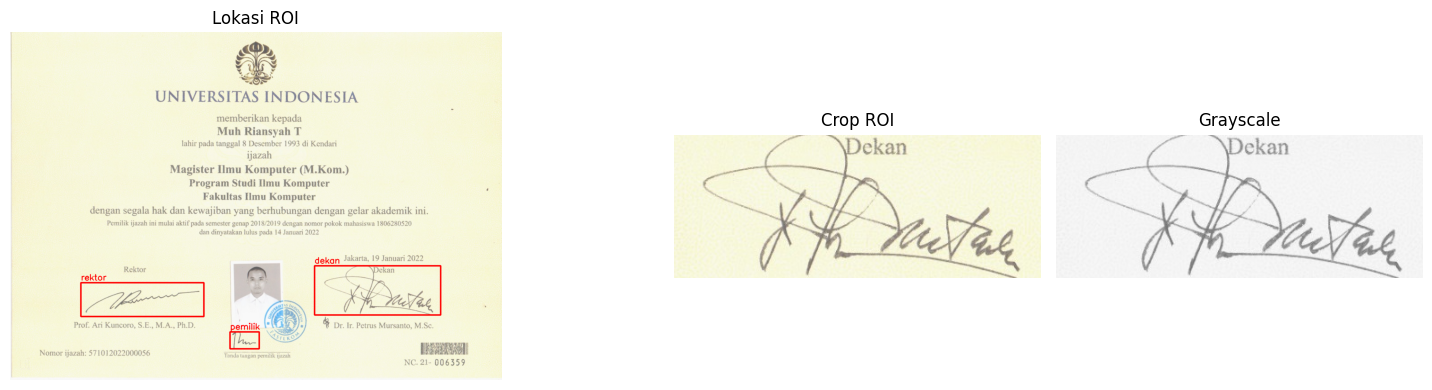

In [2]:
img = tegakkan(cv2.imread(FILES[0]))
vis = img.copy()
for n, (x1,y1,x2,y2) in ROI_POSITIF.items():
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,0,255), 3)
    cv2.putText(vis, n, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 2)
c = crop(img, ROI_POSITIF[UTAMA])

fig, ax = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'width_ratios':[2.2,1,1]})
ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lokasi ROI')
ax[1].imshow(cv2.cvtColor(c, cv2.COLOR_BGR2RGB));   ax[1].set_title('Crop ROI')
ax[2].imshow(ke_gray(c), cmap='gray', vmin=0, vmax=255); ax[2].set_title('Grayscale')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 3. Thresholding & Morfologi
Blur 5x5 + normalisasi latar → global (T=190), Otsu (dibatasi maks. 200 agar kertas kosong tidak jadi foreground), adaptive Gaussian → opening 3x3 → closing 5x5.

In [3]:
def praproses(gray):
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    latar = cv2.GaussianBlur(cv2.dilate(blur, np.ones((15,15), np.uint8)), (0,0), 15)
    return np.clip(blur.astype(np.float32) / np.maximum(latar, 1) * 255, 0, 255).astype(np.uint8)

def threshold_global(norm, T=190):
    return ((norm < T) * 255).astype(np.uint8)

def threshold_otsu(norm, cap=200):
    t, _ = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return ((norm < min(t, cap)) * 255).astype(np.uint8)

def threshold_adaptive(norm):
    return cv2.adaptiveThreshold(norm, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)

K_OPEN  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
K_CLOSE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
def morfologi(biner):
    opened = cv2.morphologyEx(biner, cv2.MORPH_OPEN, K_OPEN)
    return opened, cv2.morphologyEx(opened, cv2.MORPH_CLOSE, K_CLOSE)

METODE = {'global': threshold_global, 'otsu': threshold_otsu, 'adaptive': threshold_adaptive}
def segmentasi(gray, metode):
    biner = METODE[metode](praproses(gray))
    opened, closed = morfologi(biner)
    return biner, opened, closed

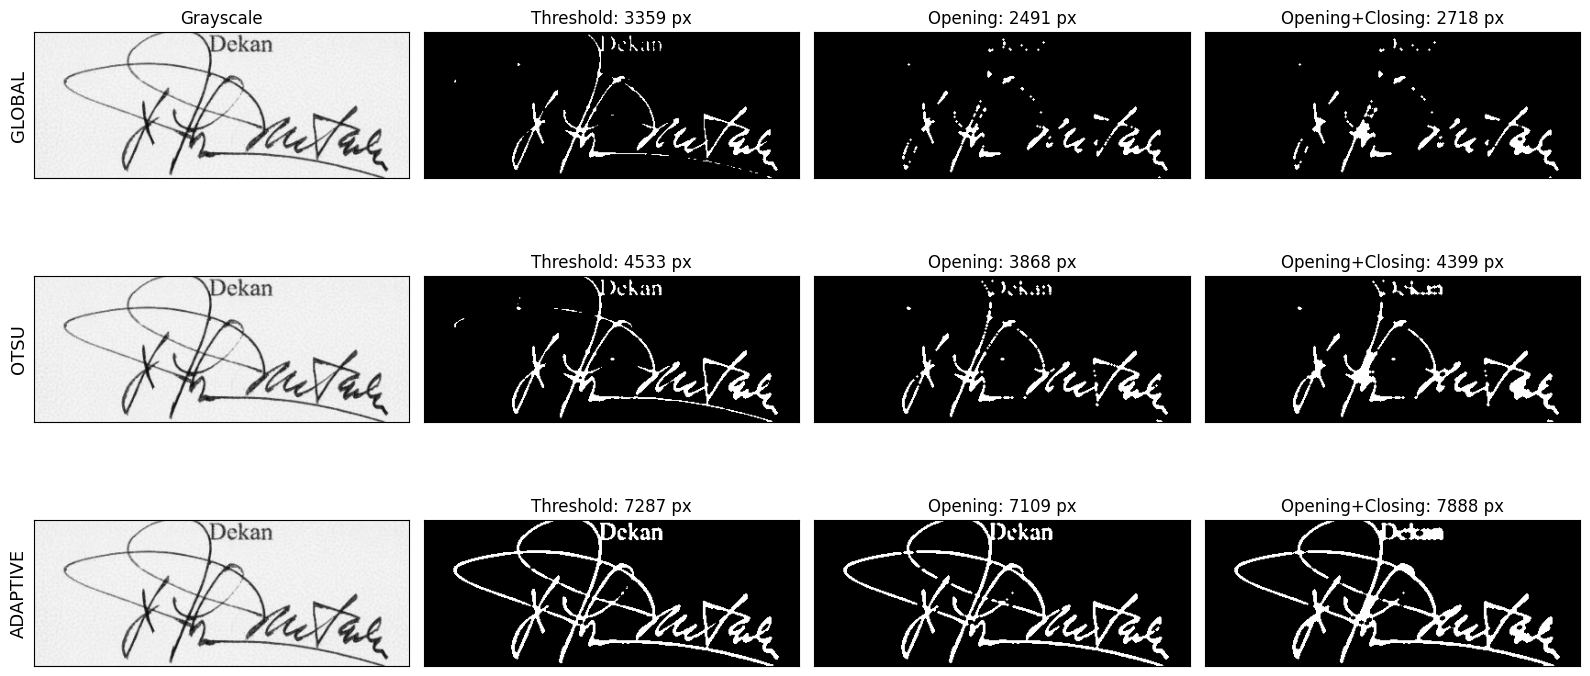

In [4]:
gray = ke_gray(crop(tegakkan(cv2.imread(FILES[0])), ROI_POSITIF[UTAMA]))
fig, ax = plt.subplots(3, 4, figsize=(16, 8))
for r, m in enumerate(METODE):
    biner, opened, closed = segmentasi(gray, m)
    ax[r,0].imshow(gray, cmap='gray'); ax[r,0].set_ylabel(m.upper(), fontsize=13)
    for c, (im, jd) in enumerate([(biner,'Threshold'), (opened,'Opening'), (closed,'Opening+Closing')], 1):
        ax[r,c].imshow(im, cmap='gray'); ax[r,c].set_title(f'{jd}: {np.count_nonzero(im)} px')
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
ax[0,0].set_title('Grayscale'); plt.tight_layout(); plt.show()

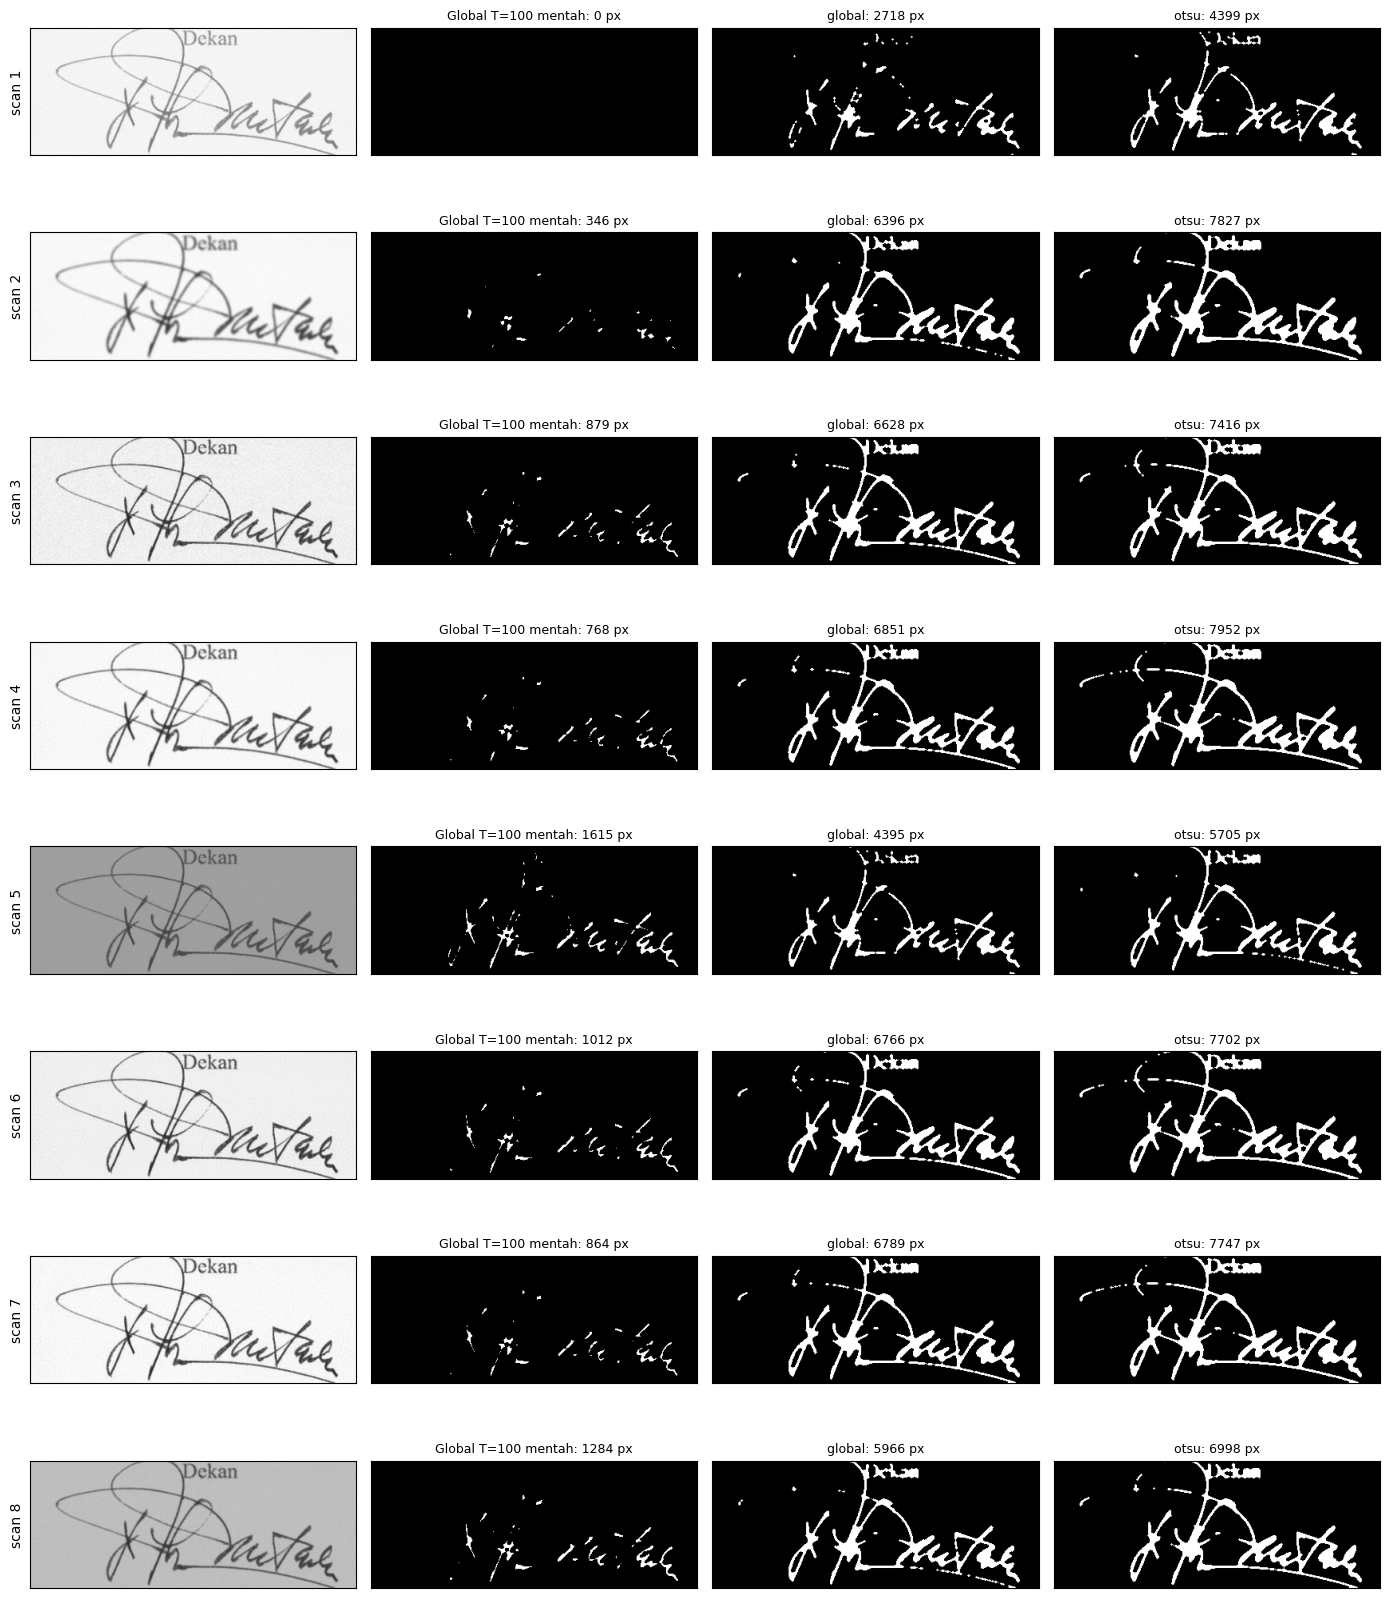

In [5]:
# Perbandingan pada seluruh scan
fig, ax = plt.subplots(len(FILES), 4, figsize=(14, 2.1*len(FILES)))
for i, f in enumerate(FILES):
    g = ke_gray(crop(tegakkan(cv2.imread(f)), ROI_POSITIF[UTAMA]))
    naif = ((cv2.GaussianBlur(g,(5,5),0) < 100)*255).astype(np.uint8)
    ax[i,0].imshow(g, cmap='gray', vmin=0, vmax=255); ax[i,0].set_ylabel(f'scan {i+1}')
    ax[i,1].imshow(naif, cmap='gray'); ax[i,1].set_title(f'Global T=100 mentah: {np.count_nonzero(naif)} px', fontsize=9)
    for c, m in enumerate(['global','otsu'], 2):
        cl = segmentasi(g, m)[2]
        ax[i,c].imshow(cl, cmap='gray'); ax[i,c].set_title(f'{m}: {np.count_nonzero(cl)} px', fontsize=9)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 4. Fitur Area & Aturan Keputusan
`PRESENT` jika rasio foreground ≥ 1% **dan** lebar komponen terbesar ≥ 25% lebar ROI (teks cetak terpecah jadi huruf kecil, tanda tangan berupa goresan menyambung).

In [6]:
MIN_FG_RATIO, MIN_LARGEST_W = 0.01, 0.25

def fitur(mask):
    n, _, st, _ = cv2.connectedComponentsWithStats(mask, 8)
    fg = int(np.count_nonzero(mask))
    if n > 1:
        i = 1 + int(np.argmax(st[1:, cv2.CC_STAT_AREA]))
        la, lw = int(st[i, cv2.CC_STAT_AREA]), st[i, cv2.CC_STAT_WIDTH] / mask.shape[1]
    else:
        la, lw = 0, 0.0
    return dict(fg_pixels=fg, fg_ratio=fg/mask.size, n_comp=n-1, largest_area=la, largest_w_ratio=lw)

def keputusan(f):
    ok = f['fg_ratio'] >= MIN_FG_RATIO and f['largest_w_ratio'] >= MIN_LARGEST_W
    return 'SIGNATURE PRESENT' if ok else 'SIGNATURE ABSENT'

def deteksi(gray, metode='otsu'):
    closed = segmentasi(gray, metode)[2]
    f = fitur(closed)
    return keputusan(f), f, closed

## 5. Pengujian
Semua scan bertanda tangan, jadi sampel ABSENT dibuat dari kertas kosong, teks cetak, dan ROI Dekan yang ditimpa kertas kosong (simulasi).

In [7]:
def buat_sampel():
    S = []
    for i, f in enumerate(FILES, 1):
        img = tegakkan(cv2.imread(f))
        for n, roi in ROI_POSITIF.items():
            S.append((f'scan{i}_{n}', ke_gray(crop(img, roi)), 'PRESENT', n))
        for n, roi in ROI_NEGATIF.items():
            S.append((f'scan{i}_{n}', ke_gray(crop(img, roi)), 'ABSENT', n))
        x1,y1,x2,y2 = ROI_POSITIF[UTAMA]
        patch = cv2.resize(crop(img, ROI_NEGATIF['kertas_kosong_1']), (x2-x1, y2-y1))
        S.append((f'scan{i}_{UTAMA}_dihapus', ke_gray(patch), 'ABSENT', f'{UTAMA}_dihapus'))
    return S

SAMPEL = buat_sampel()
rows = []
for nama, g, label, jenis in SAMPEL:
    for m in METODE:
        pred, f, _ = deteksi(g, m)
        rows.append(dict(sampel=nama, jenis=jenis, label=f'SIGNATURE {label}', metode=m, prediksi=pred,
                         benar=(pred == f'SIGNATURE {label}'), **f))
df = pd.DataFrame(rows)

def ringkas(d):
    tp = ((d.label=='SIGNATURE PRESENT') & (d.prediksi=='SIGNATURE PRESENT')).sum()
    tn = ((d.label=='SIGNATURE ABSENT')  & (d.prediksi=='SIGNATURE ABSENT')).sum()
    fp = ((d.label=='SIGNATURE ABSENT')  & (d.prediksi=='SIGNATURE PRESENT')).sum()
    fn = ((d.label=='SIGNATURE PRESENT') & (d.prediksi=='SIGNATURE ABSENT')).sum()
    return pd.Series(dict(TP=tp, TN=tn, FP=fp, FN=fn, akurasi=(tp+tn)/len(d)))

print('Total sampel:', len(SAMPEL))
display(df.groupby('metode').apply(ringkas))
display(df.pivot_table(index='jenis', columns='metode', values='benar', aggfunc='mean').round(3))

Total sampel: 72


,TP,TN,FP,FN,akurasi
metode,,,,,
adaptive,24.0,48.0,0.0,0.0,1.000000
global,23.0,48.0,0.0,1.0,0.986111
otsu,24.0,48.0,0.0,0.0,1.000000


metode,adaptive,global,otsu
jenis,,,
dekan,1.0,0.875,1.0
dekan_dihapus,1.0,1.000,1.0
kertas_kosong_1,1.0,1.000,1.0
kertas_kosong_2,1.0,1.000,1.0
kertas_kosong_3,1.0,1.000,1.0
pemilik,1.0,1.000,1.0
rektor,1.0,1.000,1.0
teks_cetak_1,1.0,1.000,1.0
teks_cetak_2,1.0,1.000,1.0


In [8]:
# Hasil ROI utama per scan (Otsu)
d = df[(df.metode=='otsu') & (df.jenis==UTAMA)][['sampel','fg_pixels','fg_ratio','largest_w_ratio','prediksi']].copy()
d['fg_ratio'] = (d.fg_ratio*100).round(2).astype(str) + '%'
display(d.round(2).reset_index(drop=True))

display(df[df.metode=='otsu'].groupby('jenis')[['fg_pixels','fg_ratio','n_comp','largest_w_ratio']].agg(['min','max']).round(3))

,sampel,fg_pixels,fg_ratio,largest_w_ratio,prediksi
0,scan1_dekan,4399,6.71%,0.28,SIGNATURE PRESENT
1,scan2_dekan,7827,11.93%,0.59,SIGNATURE PRESENT
2,scan3_dekan,7416,11.3%,0.60,SIGNATURE PRESENT
3,scan4_dekan,7952,12.12%,0.71,SIGNATURE PRESENT
4,scan5_dekan,5705,8.7%,0.32,SIGNATURE PRESENT
5,scan6_dekan,7702,11.74%,0.71,SIGNATURE PRESENT
6,scan7_dekan,7747,11.81%,0.71,SIGNATURE PRESENT
7,scan8_dekan,6998,10.67%,0.59,SIGNATURE PRESENT


fg_pixels       fg_ratio        n_comp     largest_w_ratio  \
                      min   max      min    max    min max             min   
jenis                                                                        
dekan                4399  7952    0.067  0.121      8  19           0.278   
dekan_dihapus           0     0    0.000  0.000      0   0           0.000   
kertas_kosong_1         0     0    0.000  0.000      0   0           0.000   
kertas_kosong_2         0     8    0.000  0.000      0   1           0.000   
kertas_kosong_3         0     0    0.000  0.000      0   0           0.000   
pemilik               599   886    0.115  0.170      1   2           0.611   
rektor               2049  3145    0.047  0.071      1   5           0.565   
teks_cetak_1          818  2759    0.039  0.131     13  30           0.033   
teks_cetak_2          315  2009    0.020  0.126     10  17           0.066   

                        
                   max  
jenis                   
dekan            0.710  
dekan_dihapus    0.000  
kertas_kosong_1  0.000  
kertas_kosong_2  0.005  
kertas_kosong_3  0.000  
pemilik          0.821  
rektor           0.928  
teks_cetak_1     0.233  
teks_cetak_2     0.216

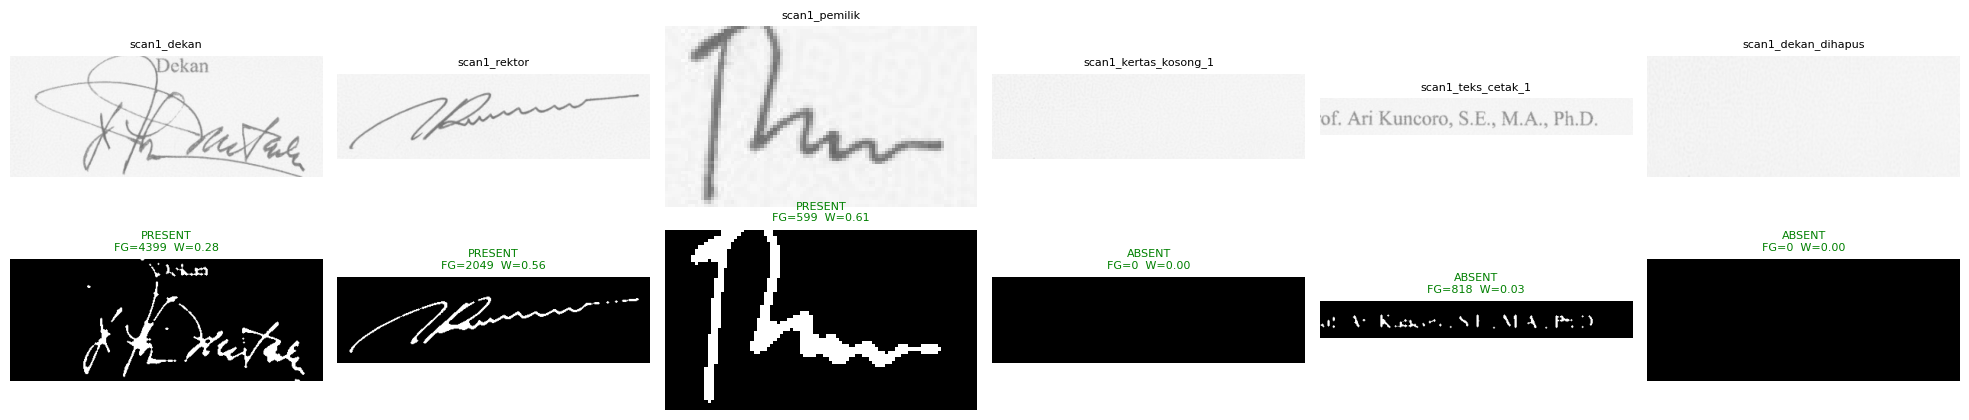

In [9]:
pilih = [f'scan1_{UTAMA}', 'scan1_rektor', 'scan1_pemilik', 'scan1_kertas_kosong_1', 'scan1_teks_cetak_1', f'scan1_{UTAMA}_dihapus']
S = {s[0]: s for s in SAMPEL}
fig, ax = plt.subplots(2, len(pilih), figsize=(3.3*len(pilih), 4.2))
for j, k in enumerate(pilih):
    _, g, label, _ = S[k]
    pred, f, mask = deteksi(g, 'otsu')
    ax[0,j].imshow(g, cmap='gray', vmin=0, vmax=255); ax[0,j].set_title(k, fontsize=8)
    ax[1,j].imshow(mask, cmap='gray')
    ax[1,j].set_title(f"{pred.replace('SIGNATURE ','')}\nFG={f['fg_pixels']}  W={f['largest_w_ratio']:.2f}", fontsize=8,
                      color='green' if pred.endswith(label) else 'red')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

## 6. Pengaruh Nilai Threshold
Variasi T global (tanpa normalisasi) pada scan dengan tinta paling terang.

Piksel tergelap per scan: [113, 53, 25, 36, 60, 27, 29, 44] -> scan terang: 1


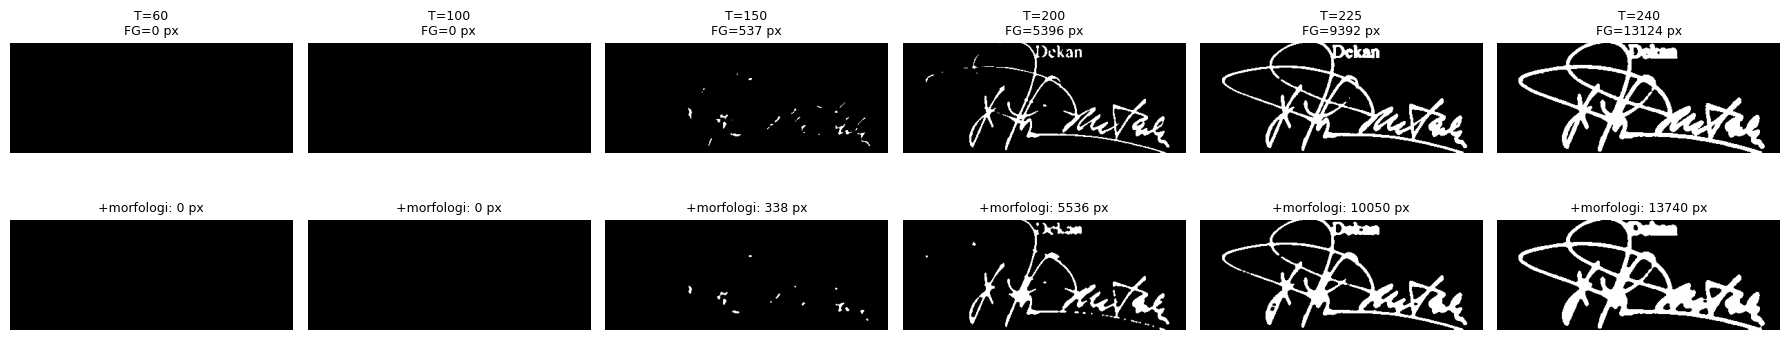

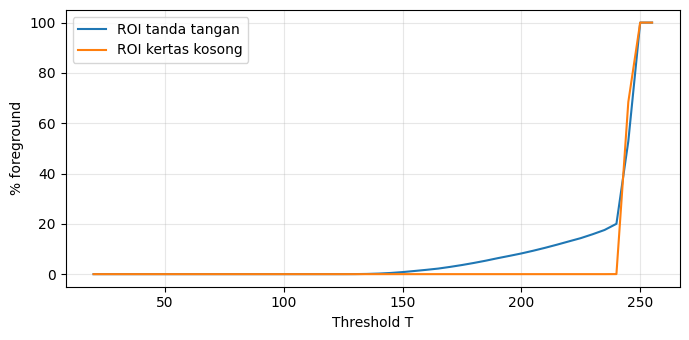

In [10]:
mins = [ke_gray(crop(tegakkan(cv2.imread(f)), ROI_POSITIF[UTAMA])).min() for f in FILES]
idx = int(np.argmax(mins))
print('Piksel tergelap per scan:', [int(m) for m in mins], '-> scan terang:', idx+1)

gb = cv2.GaussianBlur(ke_gray(crop(tegakkan(cv2.imread(FILES[idx])), ROI_POSITIF[UTAMA])), (5,5), 0)
Ts = [60, 100, 150, 200, 225, 240]
fig, ax = plt.subplots(2, len(Ts), figsize=(3*len(Ts), 4.2))
for j, T in enumerate(Ts):
    m = ((gb < T)*255).astype(np.uint8); cl = morfologi(m)[1]
    ax[0,j].imshow(m, cmap='gray');  ax[0,j].set_title(f'T={T}\nFG={np.count_nonzero(m)} px', fontsize=9)
    ax[1,j].imshow(cl, cmap='gray'); ax[1,j].set_title(f'+morfologi: {np.count_nonzero(cl)} px', fontsize=9)
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

gk = cv2.GaussianBlur(ke_gray(crop(tegakkan(cv2.imread(FILES[idx])), ROI_NEGATIF['kertas_kosong_1'])), (5,5), 0)
Tg = np.arange(20, 256, 5)
plt.figure(figsize=(7,3.5))
plt.plot(Tg, [np.mean(gb<T)*100 for T in Tg], label='ROI tanda tangan')
plt.plot(Tg, [np.mean(gk<T)*100 for T in Tg], label='ROI kertas kosong')
plt.xlabel('Threshold T'); plt.ylabel('% foreground'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()